Hi everyone. Below is my first submission to the ever famous housing regression. The apt dataset for beginners into kaggle, I realized a lot of kernels to be full of long codes that intimidated me as a beginner.

Here I've tried to optimize my code and still providing the best results which I believe will not be intimidating for beginners and learners who are trying to get their first submission. 

To anyone who views the code - an upvote will be appreciated. You know how motivating it is to keep you going. Feel free to comment out any errors or suggestions without any hesitation.

# Importing libraries and reading the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy import stats
from sklearn import ensemble, tree, linear_model
from sklearn.model_selection import train_test_split, cross_val_score
from scipy.stats import skew
import math
from sklearn.metrics import mean_squared_error
import sklearn.metrics as sklm
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_train = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
df_test = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

Getting the basic information about the data


In [3]:
df_train.shape

(1460, 81)

In [4]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [7]:
#merging the test and train data
frames = [df_train,df_test]
df = pd.concat(frames, keys=['x', 'y'])

df

Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
x 0        1          60       RL         65.0     8450   Pave   NaN      Reg   
  1        2          20       RL         80.0     9600   Pave   NaN      Reg   
  2        3          60       RL         68.0    11250   Pave   NaN      IR1   
  3        4          70       RL         60.0     9550   Pave   NaN      IR1   
  4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...      ...         ...      ...          ...      ...    ...   ...      ...   
y 1454  2915         160       RM         21.0     1936   Pave   NaN      Reg   
  1455  2916         160       RM         21.0     1894   Pave   NaN      Reg   
  1456  2917          20       RL        160.0    20000   Pave   NaN      Reg   
  1457  2918          85       RL         62.0    10441   Pave   NaN      Reg   
  1458  2919          60       RL         74.0     9627   Pave   NaN      Reg   

       LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
x 0            Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
  1            Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
  2            Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
  3            Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
  4            Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
...            ...       ...  ...      ...    ...    ...         ...     ...   
y 1454         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
  1455         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
  1456         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
  1457         Lvl    AllPub  ...        0    NaN  MnPrv        Shed     700   
  1458         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   

       MoSold YrSold  SaleType  SaleCondition  SalePrice  
x 0         2   2008        WD         Normal   208500.0  
  1         5   2007        WD         Normal   181500.0  
  2         9   2008        WD         Normal   223500.0  
  3         2   2006        WD        Abnorml   140000.0  
  4        12   2008        WD         Normal   250000.0  
...       ...    ...       ...            ...        ...  
y 1454      6   2006        WD         Normal        NaN  
  1455      4   2006        WD        Abnorml        NaN  
  1456      9   2006        WD        Abnorml        NaN  
  1457      7   2006        WD         Normal        NaN  
  1458     11   2006        WD         Normal        NaN  

[2919 rows x 81 columns]

# Missing values

Checking for the number and percentage of missing values

In [8]:
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(25)

,Total,Percent
PoolQC,2909,0.996574
MiscFeature,2814,0.964029
Alley,2721,0.932169
Fence,2348,0.804385
SalePrice,1459,0.499829
FireplaceQu,1420,0.486468
LotFrontage,486,0.166495
GarageQual,159,0.054471
GarageYrBlt,159,0.054471
GarageFinish,159,0.054471


Filling certain categorical columns about which we have an intuition using the forward fill method 

In [9]:
for column in ['Electrical', 'SaleType', 'KitchenQual', 'Exterior1st','Exterior2nd','Functional','Utilities','MSZoning']:
    df[column].fillna(method='ffill',inplace=True)

Extracting the column names of the numerical and categorical features separately and filling the rest of the missing values.

In [10]:
num_features = df.select_dtypes(include=np.number).columns.tolist()
cat_features = df.select_dtypes(exclude=np.number).columns.tolist()
num_features.remove('SalePrice')

In [11]:
df['LotFrontage'].fillna(df['LotFrontage'].mean(), inplace = True)
df[cat_features] = df[cat_features].fillna("none")
df[num_features] = df[num_features].fillna(0)

Making sure the no other values are missed. 

In [12]:
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(25)

,Total,Percent
SalePrice,1459,0.499829
Heating,0,0.000000
RoofStyle,0,0.000000
RoofMatl,0,0.000000
Exterior1st,0,0.000000
Exterior2nd,0,0.000000
MasVnrType,0,0.000000
MasVnrArea,0,0.000000
ExterQual,0,0.000000
ExterCond,0,0.000000


Creating new features as per our intuition and dropping the other columns.

In [13]:
df['TotalArea'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF'] + df['GrLivArea'] +df['GarageArea']

df['Bathrooms'] = df['FullBath'] + df['HalfBath']*0.5 

df['Year average']= (df['YearRemodAdd'] + df['YearBuilt'])/2

# Data Visualization

Checking the correlation of the numerical features

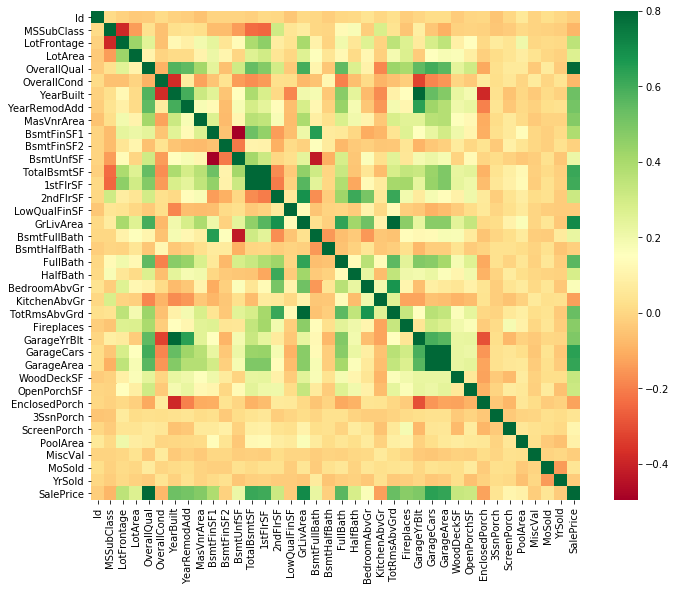

In [14]:
corrmat = df_train.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True,cmap="RdYlGn");

Zooming up the map to list the top correlations with SalePrice

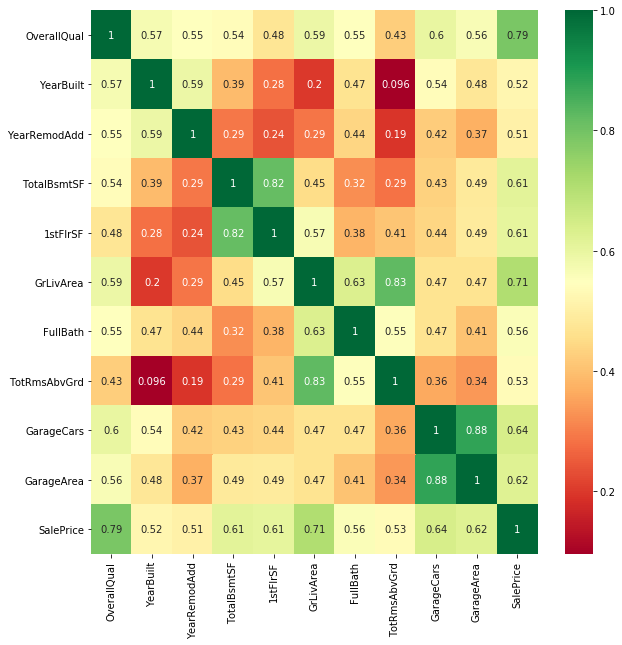

In [15]:
corrmat = df_train.corr()
top_features = corrmat.index[abs(corrmat["SalePrice"])>0.5]
plt.figure(figsize=(10,10))
g = sns.heatmap(df_train[top_features].corr(),annot=True,cmap="RdYlGn")

Getting the scatterplot for the top correlated features

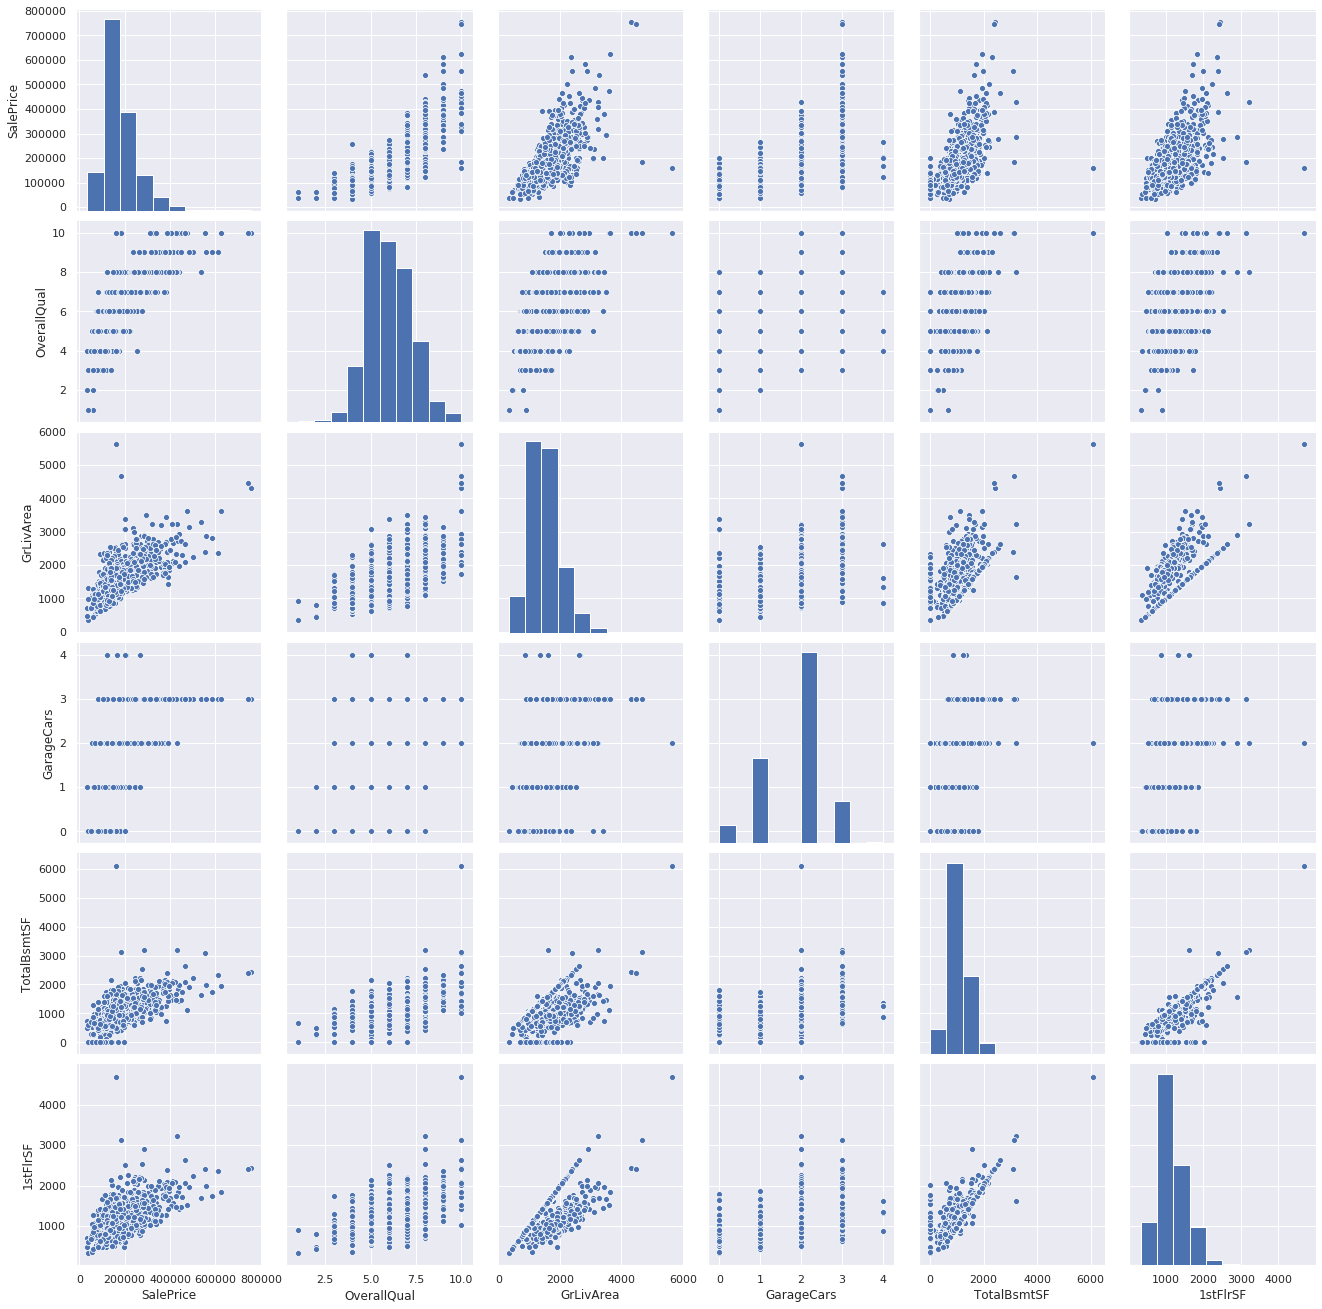

In [16]:
#scatterplot
sns.set()
columns = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', '1stFlrSF']
sns.pairplot(df_train[columns], size = 3)
plt.show();

checking for the outliers and dropping them

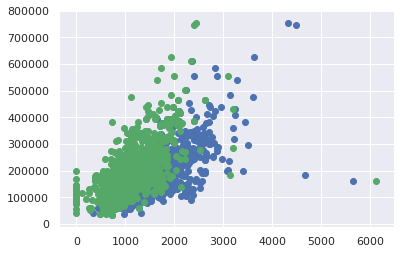

In [17]:
plt.scatter(df_train.GrLivArea, df_train.SalePrice, c = 'b')
plt.scatter(df_train.TotalBsmtSF, df_train.SalePrice, c = 'g')

In [18]:
df.shape

(2919, 84)

In [19]:
#df_train.sort_values(by = 'GrLivArea', ascending = False)[:2]
df.drop(df[df['Id'] == 1299].index, inplace = True)
df.drop(df[df['Id'] == 524].index, inplace = True)

# Transforming the data

Taking a look at the target variable. It looks skewed so we transform it to fit normal distribution

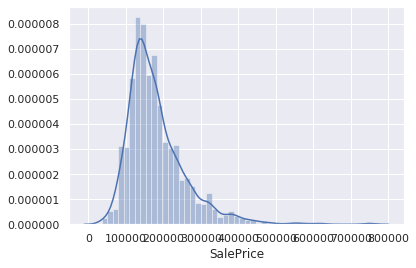

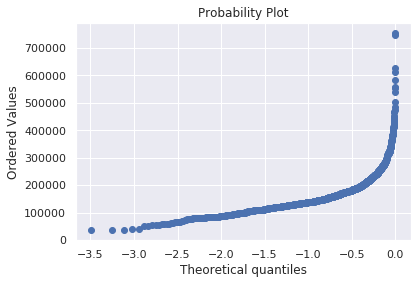

In [20]:
sns.distplot(df['SalePrice']);
fig = plt.figure()
res = stats.probplot(df['SalePrice'], plot=plt)

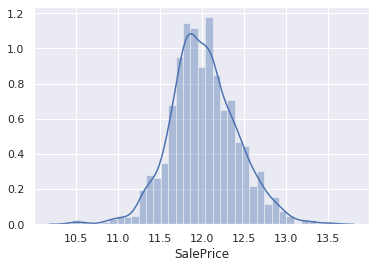

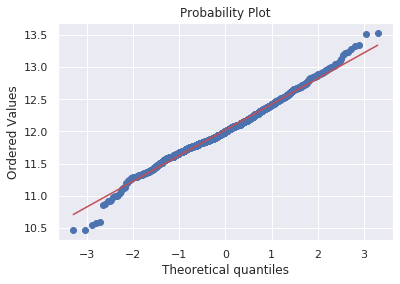

In [21]:
df_train['SalePrice'] = np.log1p(df_train['SalePrice'])
sns.distplot(df_train['SalePrice']);
fig = plt.figure()
res = stats.probplot(df_train['SalePrice'], plot=plt)

In [22]:
df['MSSubClass'] = df['MSSubClass'].apply(str)
df['YrSold'] = df['YrSold'].astype(str)

Checking the skewness of other variables and treating it.

In [23]:
df.skew(axis=0).sort_values(ascending= False).head(10)


MiscVal          21.950962
PoolArea         17.697766
LotArea          13.116240
LowQualFinSF     12.090757
3SsnPorch        11.377932
KitchenAbvGr      4.302763
BsmtFinSF2        4.146636
EnclosedPorch     4.004404
ScreenPorch       3.947131
BsmtHalfBath      3.932018
dtype: float64

In [24]:
num_features = df.select_dtypes(include=np.number).columns.tolist()
df[num_features] = np.log1p(df[num_features])

Converting the categorical columns into numerical

In [25]:
df1 = pd.get_dummies(df.drop('SalePrice', axis=1))
X_train = df1.xs('x')
X_test = df1.xs('y')

In [26]:
df_train = df_train.drop(df_train[df_train['Id'] == 1299].index)
df_train = df_train.drop(df_train[df_train['Id'] == 524].index)
y_train = df_train.iloc[:,80]

In [27]:
y_train.shape

(1458,)

# Fitting the Model

In [28]:
from sklearn.linear_model import Lasso
import sklearn.model_selection as ms
parameters= {'alpha':[0.0001,0.0009,0.001,0.01,0.1,1,10],
            'max_iter':[100,500,1000]}


lasso = Lasso()
lasso_model = ms.GridSearchCV(lasso, param_grid=parameters, scoring='neg_mean_squared_error', cv=10)
lasso_model.fit(X_train,y_train)

print('The best value of Alpha is: ',lasso_model.best_params_)

The best value of Alpha is:  {'alpha': 0.0009, 'max_iter': 500}


In [29]:
lasso_mod=Lasso(alpha=0.0009,max_iter = 500)
lasso_mod.fit(X_train,y_train)
y_lasso_train=lasso_mod.predict(X_train)
y_lasso_test=lasso_mod.predict(X_test)
math.sqrt(sklm.mean_squared_error(y_train, y_lasso_train))

0.10447484255205046